# CNN Model Training
## Goal of nb3
- train CNN models to classify these 12 animals

 ## (1) Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## (2) Set path and parameters


In [2]:
data_dir = "C:/Projects/06_WildLife_Image_Classification/Wildlife_images"
img_size = (224,224)
batch_size= 32
num_classes = 12
epochs  = 15

## (3) Create train and validation generators

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2134 images belonging to 12 classes.
Found 530 images belonging to 12 classes.


## (4) Build the CNN model

In [5]:
model = Sequential ([
    Conv2D(32, (3,3), activation="relu", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

c:\Users\shwey\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## (5) Compile the model

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## (6) Model summary

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,404 (42.62 MB)

 Trainable params: 11,170,956 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

## (7) Add Callbacks

In [8]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)

## (8) Train the model

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[early_stopping, model_checkpoint]
)

c:\Users\shwey\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3263 - loss: 8.7494

67/67 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.3697 - loss: 5.0219 - val_accuracy: 0.0811 - val_loss: 64.1691
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 65s 972ms/step - accuracy: 0.4405 - loss: 2.0122 - val_accuracy: 0.0811 - val_loss: 62.4068
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.4742 - loss: 1.8073 - val_accuracy: 0.0811 - val_loss: 39.0498
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.4973 - loss: 1.6788

67/67 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5103 - loss: 1.6882 - val_accuracy: 0.2377 - val_loss: 18.2174
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.5201 - loss: 1.6930

67/67 ━━━━━━━━━━━━━━━━━━━━ 65s 975ms/step - accuracy: 0.5361 - loss: 1.6411 - val_accuracy: 0.3925 - val_loss: 13.0696
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.5366 - loss: 1.6342

67/67 ━━━━━━━━━━━━━━━━━━━━ 64s 948ms/step - accuracy: 0.5197 - loss: 1.6873 - val_accuracy: 0.5623 - val_loss: 1.8411
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.5418 - loss: 1.5967

67/67 ━━━━━━━━━━━━━━━━━━━━ 67s 998ms/step - accuracy: 0.5506 - loss: 1.5412 - val_accuracy: 0.6925 - val_loss: 1.3448
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5726 - loss: 1.3663 - val_accuracy: 0.6774 - val_loss: 1.1919
Epoch 9/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.5755 - loss: 1.4794

67/67 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5661 - loss: 1.4457 - val_accuracy: 0.7736 - val_loss: 0.6990
Epoch 10/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5801 - loss: 1.3668 - val_accuracy: 0.6528 - val_loss: 1.0350
Epoch 11/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 65s 969ms/step - accuracy: 0.6232 - loss: 1.2798 - val_accuracy: 0.6547 - val_loss: 2.2152
Epoch 12/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 62s 931ms/step - accuracy: 0.6378 - loss: 1.2106 - val_accuracy: 0.7642 - val_loss: 0.8062
Epoch 13/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.6537 - loss: 1.1388

67/67 ━━━━━━━━━━━━━━━━━━━━ 64s 950ms/step - accuracy: 0.6537 - loss: 1.1814 - val_accuracy: 0.7830 - val_loss: 0.6865
Epoch 14/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.6591 - loss: 1.1008

67/67 ━━━━━━━━━━━━━━━━━━━━ 62s 930ms/step - accuracy: 0.6635 - loss: 1.0677 - val_accuracy: 0.8057 - val_loss: 0.8840
Epoch 15/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 63s 933ms/step - accuracy: 0.6888 - loss: 1.1028 - val_accuracy: 0.6792 - val_loss: 2.2952


## (9) Plot training history

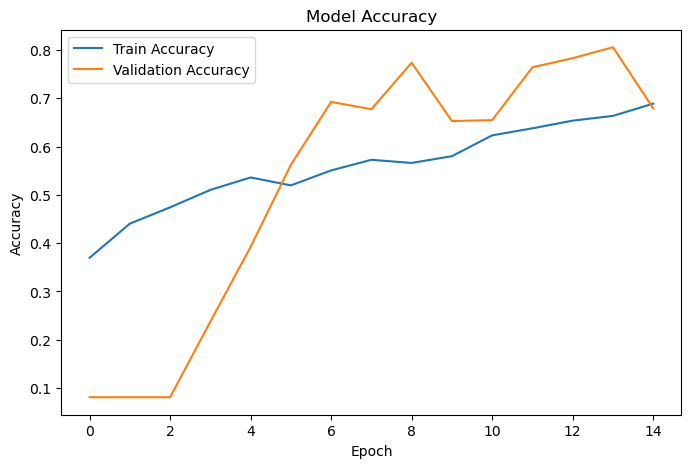

In [10]:
## Accuracy plot

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

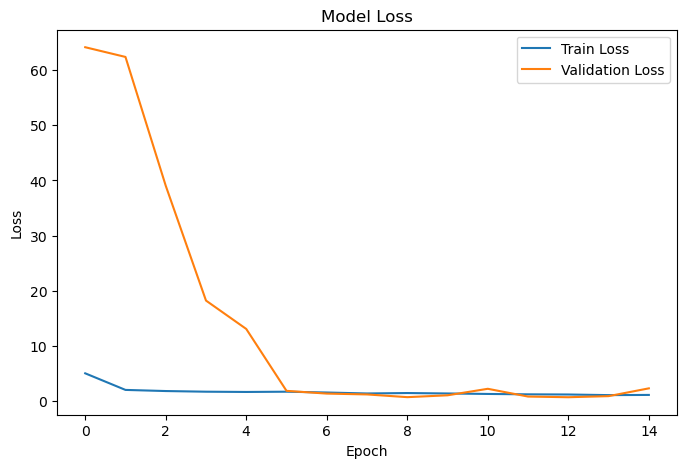

In [11]:
## Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## (10) Evaluate the model

In [12]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Loss: {val_loss: .4f}")
print(f"Validation Accuracy: {val_acc: .4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - accuracy: 0.7830 - loss: 0.6865
Validation Loss:  0.6865
Validation Accuracy:  0.7830
